In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_ROOT = '../data'

In [3]:
PCC_200_randn_all = pd.read_csv(f'{DATA_ROOT}/PEARSONS_200_randn_all_results.csv', index_col= 0, header = 0)

In [27]:
External_PCC_200_randn_all = pd.read_csv(f'./data/external_PEARSONS_200_randn_all.csv', index_col=0)
#remove models that did not evaluate
External_PCC_200_randn_all = External_PCC_200_randn_all[~External_PCC_200_randn_all['external_set_score'].isna()]
External_PCC_200_randn_all.columns = ['External PCC']
External_PCC_200_randn_all['External PCC'] = 1 - External_PCC_200_randn_all['External PCC']

In [28]:
External_PCC_200_randn_all['External PCC'].describe()

count    2873.000000
mean        0.581899
std         0.276548
min        -0.236299
25%         0.401187
50%         0.666663
75%         0.803614
max         0.961449
Name: External PCC, dtype: float64

<Axes: >

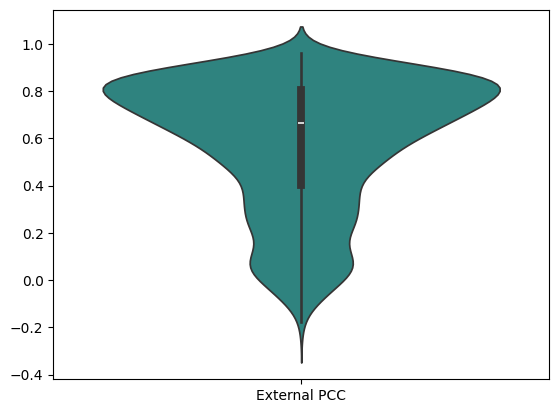

In [29]:
sns.violinplot(data = External_PCC_200_randn_all, palette = 'viridis')


In [5]:
np.sum(PCC_200_randn_all['stopped_early'])

np.float64(10.0)

In [6]:
TPM_res.shape

NameError: name 'TPM_res' is not defined

In [ ]:
np.sum(TPM_res['stopped_early'])

16097.0

In [ ]:
TPM_res

,train_score,test_score,stopped_early
A2M,0.969889,0.961446,1.0
A2ML1,1.145598,1.169069,1.0
A3GALT2,0.847709,0.856579,1.0
A4GALT,0.534433,0.527976,1.0
AAAS,0.322987,0.324133,1.0
...,...,...,...
ZYG11A,1.416881,1.392014,1.0
ZYG11B,0.399702,0.410859,1.0
ZYX,0.279193,0.281179,1.0
ZZEF1,0.329884,0.330753,1.0


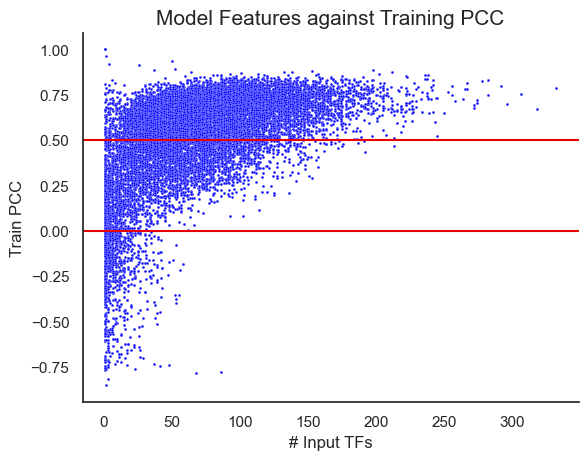

In [ ]:
TPM_res.loc[TPM_res['test_score'] < 0.2, :].shape[0]

In [ ]:
#log_to_plot = pd.melt(logTPM_res)
TPM_to_plot = pd.melt(TPM_res)

In [ ]:
#create function make train test MSE violin plot
def loss_violin_plot(df, palette, title, figtitle):
    fig, ax = plt.subplots()
    ax = sns.violinplot(data = df, x = 'variable', y="value", hue = 'variable', palette=palette)
    ax.set_ylabel('MSE', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
    fig.canvas.draw()
    labels = [item.get_text() for item in ax.get_xticklabels()]
    labels[0], labels[1] = ['Training', 'Test']
    ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
    fig.suptitle(title, fontsize = 20)
    plt.savefig(figtitle, dpi = 300)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_8909/1421562481.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


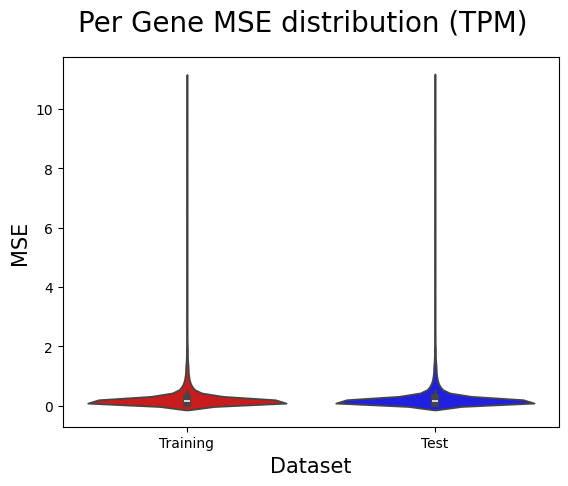

In [ ]:
loss_violin_plot(TPM_to_plot, palette=['#e60000', '#0000ff'], title ='Per Gene MSE distribution (TPM)', figtitle= 'figures/TPM_train_test')

# External dataset erorr scores

ValueError: Could not interpret value `log_external` for `y`. An entry with this name does not appear in `data`.

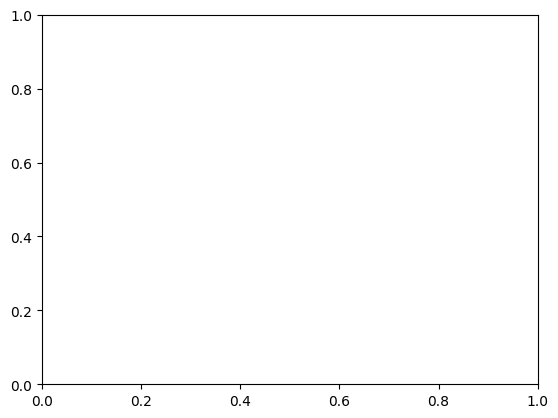

In [ ]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'log_external', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Log(External MSE + 1)', fontsize = 10)
fig.suptitle('Training vs External MSE and Model Size')
plt.savefig('figures/trainVSextVSModel', bbox_inches='tight')

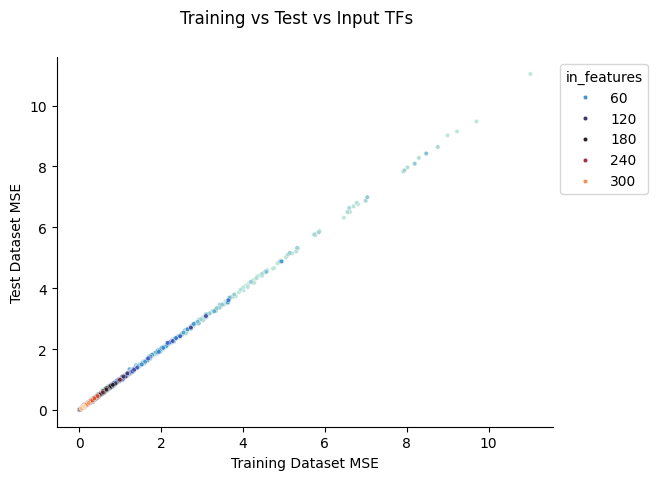

In [ ]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'test_score', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Test Dataset MSE', fontsize = 10)
fig.suptitle('Training vs Test vs Input TFs')
plt.savefig('figures/trainVsTestvsModel', bbox_inches='tight')

In [ ]:
external_res.loc[external_res['external_set_score'] < 1].shape

(13446, 2)

In [ ]:
external_res['log'] = np.log(external_res['external_set_score'] + 1)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_88664/1795373650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])


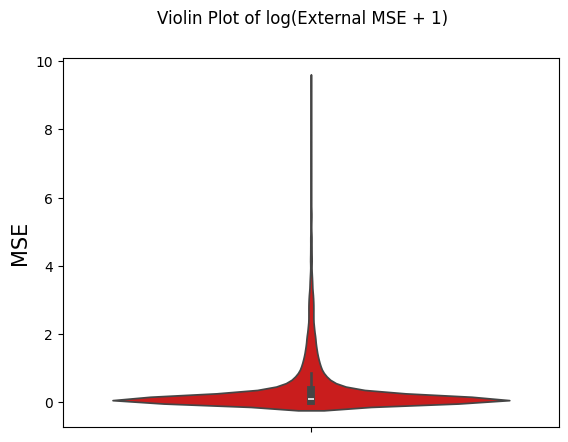

In [ ]:
fig, ax = plt.subplots()
ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])
ax.set_ylabel('MSE', fontsize = 15)
fig.suptitle('Violin Plot of log(External MSE + 1)')
plt.show()
#ax.set_xlabel('Dataset', fontsize = 15)
#fig.canvas.draw()
#labels = [item.get_text() for item in ax.get_xticklabels()]
#labels[0], labels[1] = ['Training', 'Test']
#ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
#fig.suptitle(title, fontsize = 20)
#plt.savefig(figtitle, dpi = 300)

# Correlation and MSE plots

In [ ]:
from_train_losses = results[['train_loss', 'test_loss']].melt()
from_train_losses.columns = ['dataset', 'value']

In [ ]:
from_train_losses['value'] = 1 - from_train_losses['value']

In [ ]:
genewise_correlations['LogMSE'] = np.log(genewise_correlations['MSE']+1)

In [ ]:
from_train_losses

,dataset,value
0,train_loss,0.031068
1,train_loss,-0.174456
2,train_loss,-0.094459
3,train_loss,0.417640
4,train_loss,0.681664
...,...,...
32195,test_loss,-0.214892
32196,test_loss,0.581442
32197,test_loss,0.728245
32198,test_loss,0.761174


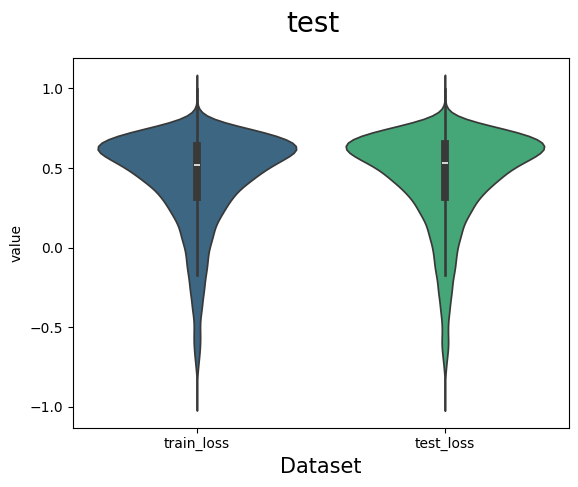

In [ ]:
create_pearsons_violin(from_train_losses, y_col = 'value', title = 'test', file_title = 'TEMP')